# Support2 Data EDA

## 1. Load libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo


from scipy.stats import gaussian_kde    # We use this to plot kernel density

## 2 Data ingestion

In [4]:
# 880 is the ID for the Support2 data.
support2 = fetch_ucirepo(id=880)

# Load the entire dataset into a pandas dataframe
# support2.data.features does not include some variables that we are interested
df = support2.data.original
display(df.head(n=2))

,id,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0


In [5]:
# Summary print outs
print(50*"+-")
print("Online data dictionary")
print("https://archive.ics.uci.edu/dataset/880/support2")

print(50*"+-")
print("Column names:\n", df.columns)

print(50*"+-")
print("Shape of the data: ", df.shape)



+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
Online data dictionary
https://archive.ics.uci.edu/dataset/880/support2
+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
Column names:
 Index(['id', 'age', 'death', 'sex', 'hospdead', 'slos', 'd.time', 'dzgroup',
       'dzclass', 'num.co', 'edu', 'income', 'scoma', 'charges', 'totcst',
       'totmcst', 'avtisst', 'race', 'sps', 'aps', 'surv2m', 'surv6m', 'hday',
       'diabetes', 'dementia', 'ca', 'prg2m', 'prg6m', 'dnr', 'dnrday',
       'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea',
       'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'sfdm2',
       'adlsc'],
      dtype='object')
+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
Shape of the data:  (9105, 48)


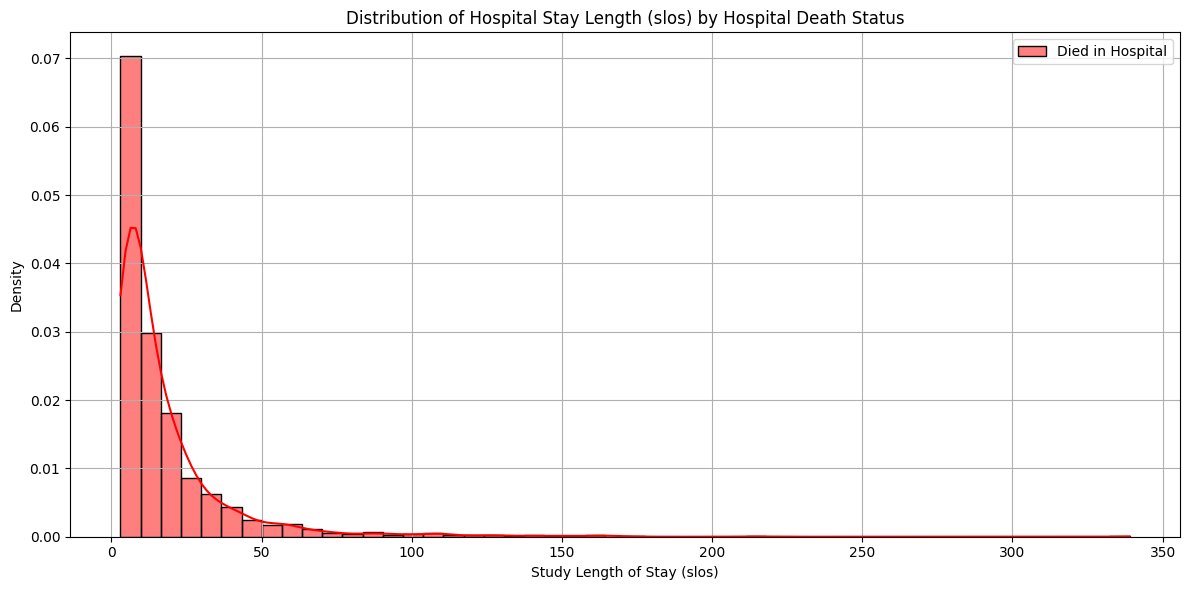

In [6]:
df_dead = df[df["hospdead"] == 1]
df_alive = df[df["hospdead"] == 0]

# Plot
plt.figure(figsize=(12, 6))
sns.histplot(df_dead["slos"], bins=50, color='red', label='Died in Hospital', stat='density', kde=True)
#sns.histplot(df_alive["slos"], bins=50, color='blue', label='Discharged Alive', stat='density', kde=True)
plt.xlabel("Study Length of Stay (slos)")
plt.ylabel("Density")
plt.title("Distribution of Hospital Stay Length (slos) by Hospital Death Status")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3 Data preprocessing

In [7]:
# Limiting the examples to patients passed away while hospitalized
df = df[df.hospdead == 1]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2360 entries, 1 to 9103
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        2360 non-null   int64  
 1   age       2360 non-null   float64
 2   death     2360 non-null   int64  
 3   sex       2360 non-null   object 
 4   hospdead  2360 non-null   int64  
 5   slos      2360 non-null   int64  
 6   d.time    2360 non-null   int64  
 7   dzgroup   2360 non-null   object 
 8   dzclass   2360 non-null   object 
 9   num.co    2360 non-null   int64  
 10  edu       1747 non-null   float64
 11  income    1465 non-null   object 
 12  scoma     2359 non-null   float64
 13  charges   2299 non-null   float64
 14  totcst    2084 non-null   float64
 15  totmcst   1317 non-null   float64
 16  avtisst   2353 non-null   float64
 17  race      2341 non-null   object 
 18  sps       2359 non-null   float64
 19  aps       2359 non-null   float64
 20  surv2m    2359 non-null   float64
 

In [8]:
# Now that we selected patients 
# Check that the value of "death" and "hospdead" is uniformly "1".
print(50*"+-")
print("'death' and 'hospdeath' columns are all '1's?")
print(df.death.unique().all() == 1 and df.hospdead.unique().all() == 1)

# Drop columns that are now constant or irrelevant
df.drop(columns=["death", "hospdead"], inplace=True)



+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
'death' and 'hospdeath' columns are all '1's?
True


/tmp/ipykernel_2055/1861666265.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["death", "hospdead"], inplace=True)


In [9]:
print("'slos' column contains NA or null?")
print(df.slos.isna().any() == 1)


'slos' column contains NA or null?
False


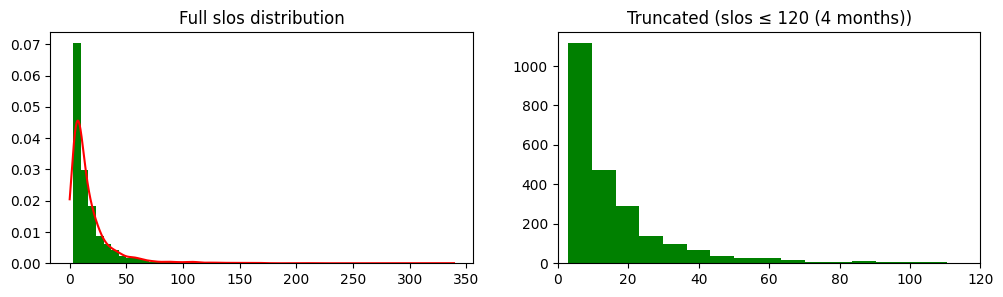

In [10]:
df.shape
fig, ax = plt.subplots(1, 2,
                       figsize=(12,3))

ax[0].hist(df.slos,
           color='green',
           bins=50,
           density=True)

x_grid = np.linspace(0, df["slos"].max(), 1000)
ax[0].plot(x_grid, gaussian_kde(df["slos"])(x_grid), color="red", label="KDE")

#ax[0].plot(np.linspace(0, df.slos.max(), 100), gaussian_kde(df.slos), color="red", label="KDE")

ax[0].set_title("Full slos distribution")

ax[1].hist(df.slos, 
           color='green',
           bins=50)

ax[1].set_xlim(0, 120)  # limit x-axis range
ax[1].set_title("Truncated (slos ≤ 120 (4 months))")

plt.show()

In [ ]:
# Vars to keep: age, sex

display(df.sex.describe())
df.sex.info()


df.sex = df.sex.map({"male": 0, "male": 1})

count     2360
unique       2
top       male
freq      1305
Name: sex, dtype: object

<class 'pandas.core.series.Series'>
Index: 2360 entries, 1 to 9103
Series name: sex
Non-Null Count  Dtype 
--------------  ----- 
2360 non-null   object
dtypes: object(1)
memory usage: 36.9+ KB


/tmp/ipykernel_2055/2267812708.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sex = df.sex.map({"male": 0, "female": 1})


### 3.1 Notes on features
 - 'dzgroup' looks like the granular version of ~~dzclass~~. For now keep dzgroup. 
 - 'num.co' integer w/o missing values.
 - 'sex' has no missing values, 
 - 'edu' contains 613 and is turned into one-hot.
 - 'd.time' days of follow-up. int. No missing values.
 - 'income' category.
 - 'race' missing value taken care off.
 - 'hday' day in hospital at which patient entered study. Mostly 1. No missing
 - 'diabetes', 0 for no and 1 for yes. No missing.
 - 'dementia', 0 for no and 1 for yes. No missing.
 - 'ca', cancer, 'no', 'yes', 'matastatic'. No missing.
 - 'meanbp'. Too suspicous to use. Bimodal. Very likely some where systolic and some were diastolic.
 - 'wblc' has missing values ~30
 - 'hrt' No missing.
 - 'resp' No missing.
 - 'temp' No missing.
 - 'pafi' has missing values  ~400. Oxygen pressure ratio, widely used (at the time) but controversial.
 - 'alb' has missing values ~900
 - 'bili' has missing values ~600
 - 'crea' has missing values 11
 - 'sod' no missing value.
 - 'ph' missing values ~400
 - 'glucose' has missing values ~1200
 - 'bun' has missing values ~1200
 - 'urine' has missing values ~1300
 - 'adlsc' calibrated activity index, no missing values.
 


 - 'scoma', one missing value. derived. Drop if we were to use the model to predict more general population outside this sample
 - Dropped three chages features: charges, totcst, totmcst, sps, aps, surv2m, surv6m, prg2m, prg6m, dnr, dnrday, adlp and adls (daily activity, adlp has only 195 values)
  

In [12]:
display(df.edu.describe())
display(df.edu.value_counts())
#pd.get_dummies(df, col)

count    1747.000000
mean       11.847167
std         3.619993
min         0.000000
25%        10.000000
50%        12.000000
75%        14.000000
max        30.000000
Name: edu, dtype: float64

edu
12.0    573
16.0    168
14.0    158
8.0     137
10.0    124
11.0    105
9.0      69
13.0     68
18.0     52
7.0      50
6.0      49
15.0     42
20.0     27
17.0     25
3.0      24
4.0      21
0.0      12
19.0     12
5.0      11
2.0       6
21.0      6
24.0      3
22.0      2
30.0      1
1.0       1
26.0      1
Name: count, dtype: int64

In [ ]:
# Define a function that turns education years into bins including 'missing'
def edu_bins(edu):
    if pd.isna(edu):
        return "missing"
    elif edu < 12:
        return "pre_hs" # did not complete highschool 
    elif edu == 12:
        return "highschool"
    elif edu < 16:
        return "some_college"
    else:
        return "college_or_higher"

df["edu_bins"] = df.edu.apply(edu_bins)
df["edu_bins"]

# Define a function that turns income into bins including 'missing'
def income_bins(inc):
    if pd.isna(inc):
        return "missing"
    elif inc == "under $11k":
        return "<$11k" # change format for consistency
    else:
        return inc  # All other cases are fine

df["income_bins"] = df.income.apply(income_bins)
np.random()
df["income_bins"]

df["race"] = df["race"].fillna("missing")

/tmp/ipykernel_2055/1965213346.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["edu_bins"] = df.edu.apply(edu_bins)
/tmp/ipykernel_2055/1965213346.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["income_bins"] = df.income.apply(income_bins)
/tmp/ipykernel_2055/1965213346.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

In [14]:
df["income_bins"].describe()

df["income_bins"].value_counts()

income_bins
missing     895
<$11k       703
$11-$25k    361
$25-$50k    243
>$50k       158
Name: count, dtype: int64

### Check data

In [21]:
display(df["adlsc"].describe())
display(df["adlsc"].value_counts())

count    2360.000000
mean        2.316259
std         2.097253
min         0.000000
25%         0.000000
50%         2.160889
75%         3.467285
max         7.000000
Name: adlsc, dtype: float64

adlsc
0.000000    685
1.000000    249
6.000000    131
2.000000    114
7.000000    111
           ... 
2.872070      1
4.991211      1
5.993164      1
2.309082      1
2.104492      1
Name: count, Length: 750, dtype: int64

<Axes: xlabel='wblc', ylabel='Density'>

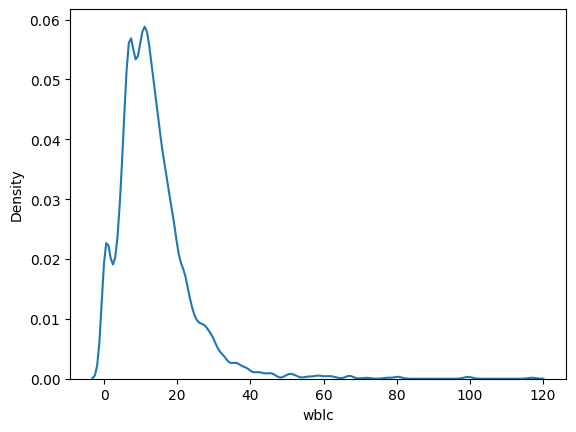

In [40]:
sns.kdeplot(df["wblc"], bw_adjust=0.5)


# End
